In [2]:
import os
import numpy as np
import shutil

for m in [0, 1, 2, 3]:
    for t in np.arange(0, 120, 20):

        src = f"/projects/academic/nguyenh/Peter/RNA-homopolymers/pmf-temp/temp-runs/rA30/Na20/Mg{m}/t-{t}/rgyr.t{t}.dat"
        dst_dir = f"/projects/academic/nguyenh/Peter/RNA-homopolymers/analysis-scripts/manuscript-final/Fig4/rA30/Na20/Mg{m}/t-{t}"

        # Create destination directory if it doesn't exist
        os.makedirs(dst_dir, exist_ok=True)

        # Copy file
        shutil.copy(src, dst_dir)

        print(f"Copied t={t}")

Copied t=0
Copied t=20
Copied t=40
Copied t=60
Copied t=80
Copied t=100
Copied t=0
Copied t=20
Copied t=40
Copied t=60
Copied t=80
Copied t=100
Copied t=0
Copied t=20
Copied t=40
Copied t=60
Copied t=80
Copied t=100
Copied t=0
Copied t=20
Copied t=40
Copied t=60
Copied t=80
Copied t=100


### Fig 4A.

<Figure size 360x360 with 0 Axes>

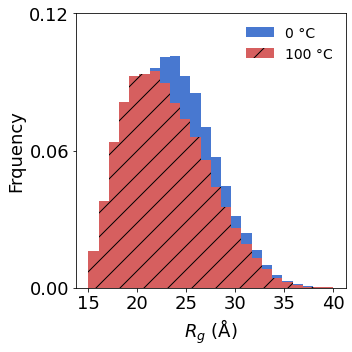

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

curr_dir = os.getcwd()
plt.figure(figsize=(5,5))
colors = sns.color_palette("muted")
bins = np.linspace(15, 40, 25)
r_20 = np.loadtxt(f"{curr_dir}/rU30/Na20/Mg5/t-0/rgyr.t0.dat")
r_100 = np.loadtxt(f"{curr_dir}/rU30/Na20/Mg5/t-100/rgyr.t100.dat")

# --- Histogram plot ---
plt.figure(figsize=(5,5))
counts20, _ = np.histogram(r_20, bins=bins)
counts100, _ = np.histogram(r_100, bins=bins)

counts20 = counts20 / counts20.sum()
counts100 = counts100 / counts100.sum()

plt.bar(bins[:-1], counts20, width=np.diff(bins),
        align="edge", color=colors[0], alpha=1,
        label=r"0 °C", zorder=2)

# plt.bar(bins[:-1], counts100, width=np.diff(bins), alpha=0,
#         align="edge", color="black", edgecolor=None, hatch="/",
#         label=r"100 °C", zorder=2)
plt.bar(bins[:-1], counts100, width=np.diff(bins), alpha=1,
        align="edge", color="#d65f5f", zorder=3, label=r"100 °C", hatch="/")


plt.xlabel(r"$R_g$ (Å)", fontsize=18)
plt.ylabel("Frquency", fontsize=18)
plt.legend(frameon=False, fontsize=14)
plt.yticks([0, 0.06, 0.12])
plt.xticks(np.arange(15, 45, 5))
plt.tick_params(axis='both', which='major', labelsize=18, direction='out')
plt.tight_layout()
#plt.savefig("/projects/academic/nguyenh/Peter/RNA-homopolymers/manuscript-figures/rU-Rg-0-vs-100C-5mM-Mg.png", dpi=300)
plt.show()

### Fig 4B

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def bootstrap_std(data, n_bootstrap=1000):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return np.std(means)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def quad_fit_with_uncertainty(T, R, sigma=None):
    T = np.asarray(T, float)
    R = np.asarray(R, float)
    if sigma is not None:
        sigma = np.asarray(sigma, float)
        # avoid zero weights
        w = 1.0 / np.clip(sigma, 1e-12, None)
    else:
        w = None

    # Fit quadratic: R = a T^2 + b T + c
    if w is None:
        p, cov = np.polyfit(T, R, 2, cov=True)
    else:
        p, cov = np.polyfit(T, R, 2, w=w, cov=True)
    a, b, c = p

    # Predicted values and R^2
    R_fit = np.polyval(p, T)
    r2 = r2_score(R, R_fit)

    # Tmax and its uncertainty via error propagation
    # Tmax = -b/(2a)
    Tmax = -b / (2*a)
    # partials: dT/da = b/(2a^2), dT/db = -1/(2a)
    dT_da = b / (2 * a**2)
    dT_db = -1.0 / (2 * a)
    var_a = cov[0,0]
    var_b = cov[1,1]
    cov_ab = cov[0,1]
    var_T = (dT_da**2) * var_a + (dT_db**2) * var_b + 2 * dT_da * dT_db * cov_ab
    Tmax_se = np.sqrt(var_T) if var_T > 0 else np.nan

    # Peak Rg at Tmax
    Rg_max = a*Tmax**2 + b*Tmax + c

    return dict(coeff=(a,b,c), cov=cov, Tmax=Tmax, Tmax_se=Tmax_se,
                Rg_max=Rg_max, R_fit=R_fit, r2=r2)

# Report
def report(name, res):
    a,b,c = res['coeff']
    print(f"=== {name} (quadratic fit) ===")
    print(f"a = {a:.5e}, b = {b:.5e}, c = {c:.5f}")
    print(f"Tmax = {res['Tmax']:.2f} ± {res['Tmax_se']:.2f} °C")
    print(f"Rg(Tmax) ≈ {res['Rg_max']:.3f} Å")
    print(f"R² = {res['r2']:.3f}\n")
    
def slope_at(T, coef):
    a, b, c = coef
    return 2*a*T + b

=== rA30 (0 mM Mg2+) (quadratic fit) ===
a = -3.79715e-04, b = 5.79601e-02, c = 27.18628
Tmax = 76.32 ± 1.00 °C
Rg(Tmax) ≈ 29.398 Å
R² = 0.999

=== rA30 (1 mM Mg2+) (quadratic fit) ===
a = -3.82442e-04, b = 4.48142e-02, c = 24.60258
Tmax = 58.59 ± 0.89 °C
Rg(Tmax) ≈ 25.915 Å
R² = 0.994

=== rA30 (2 mM Mg2+) (quadratic fit) ===
a = -3.29856e-04, b = 3.59012e-02, c = 23.73555
Tmax = 54.42 ± 0.92 °C
Rg(Tmax) ≈ 24.712 Å
R² = 0.991

=== rA30 (3 mM Mg2+) (quadratic fit) ===
a = -2.68094e-04, b = 2.96051e-02, c = 23.40718
Tmax = 55.21 ± 1.23 °C
Rg(Tmax) ≈ 24.224 Å
R² = 0.986

=== rA30 (5 mM Mg2+) (quadratic fit) ===
a = -2.54528e-04, b = 2.79262e-02, c = 23.06637
Tmax = 54.86 ± 3.42 °C
Rg(Tmax) ≈ 23.832 Å
R² = 0.883

=== rU30 (0 mM Mg2+) (quadratic fit) ===
a = -1.52251e-04, b = 1.47052e-02, c = 29.08370
Tmax = 48.29 ± 2.49 °C
Rg(Tmax) ≈ 29.439 Å
R² = 0.918

=== rU30 (1 mM Mg2+) (quadratic fit) ===
a = -1.90251e-04, b = 5.72041e-03, c = 26.09327
Tmax = 15.03 ± 4.95 °C
Rg(Tmax) ≈ 26.136 Å
R² =

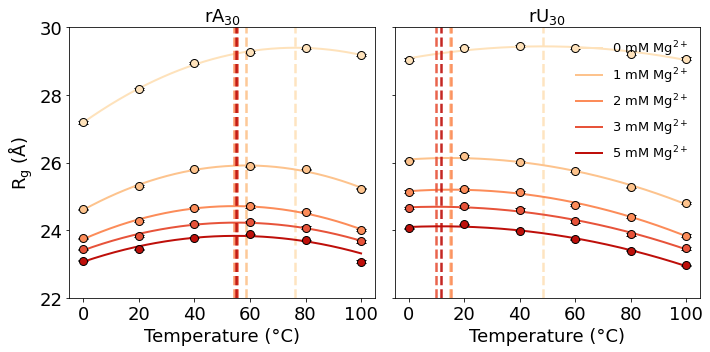

In [3]:
curr_dir = os.getcwd()

temps = np.arange(0, 120, 20)
mg_list = [0, 1, 2, 3, 5]
colors = sns.color_palette("OrRd", n_colors=len(mg_list))


def load_rg_data(system, mg, temps):
    """Load Rg data across temperatures for one system and Mg concentration."""
    means = []
    errs = []

    for T in temps:
        fname = os.path.join(
            curr_dir,
            system,
            "Na20",
            f"Mg{mg}",
            f"t-{T}",
            f"rgyr.t{T}.dat"
        )

        r = np.loadtxt(fname)
        means.append(np.mean(r))
        errs.append(bootstrap_std(r, n_bootstrap=1000))

    return np.array(means), np.array(errs)


def analyze_system(system, temps, mg_list):
    """Load Rg, fit quadratic curves, and return all results."""
    results = {}

    for mg in mg_list:
        means, errs = load_rg_data(system, mg, temps)
        fit = quad_fit_with_uncertainty(temps, means, sigma=errs)

        results[mg] = {
            "means": means,
            "errs": errs,
            "fit": fit,
            "poly": np.poly1d(fit["coeff"])
        }

        report(f"{system} ({mg} mM Mg2+)", fit)

    return results


def plot_system(ax, system, results, temps, T_smooth, colors):
    """Plot Rg vs temperature with quadratic fits for one system."""
    for i, mg in enumerate(mg_list):
        res = results[mg]

        ax.errorbar(
            temps,
            res["means"],
            yerr=res["errs"],
            fmt="o",
            capsize=5,
            color="black",
            markerfacecolor=colors[i],
            markeredgecolor="black",
            markersize=8
        )

        ax.plot(
            T_smooth,
            res["poly"](T_smooth),
            color=colors[i],
            lw=2,
            label=fr"{mg} mM Mg$^{{2+}}$"
        )

        ax.axvline(
            res["fit"]["Tmax"],
            color=colors[i],
            lw=2.5,
            ls="--",
            alpha=0.9
        )

    ax.set_title(system.replace("30", r"$_{30}$"), fontsize=18)
    ax.set_xlabel(r"Temperature (°C)", fontsize=18)
    ax.set_xticks(np.arange(0, 120, 20))
    ax.tick_params(axis="both", which="major", labelsize=18)


# Analysis
T_smooth = np.linspace(temps.min(), temps.max(), 400)

results_rA = analyze_system("rA30", temps, mg_list)
results_rU = analyze_system("rU30", temps, mg_list)


# Plot
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 5),
    sharey=True
)

plot_system(axes[0], "rA30", results_rA, temps, T_smooth, colors)
plot_system(axes[1], "rU30", results_rU, temps, T_smooth, colors)

axes[0].set_ylabel(r"R$_\mathrm{g}$ ($\mathrm{\AA}$)", fontsize=18)
axes[0].set_yticks(np.arange(22, 32, 2))

axes[1].legend(
    frameon=False,
    fontsize=13,
    loc="best"
)

plt.tight_layout()
plt.savefig("Fig4B.svg", dpi=300)
plt.show()


# Tmax
Tmax_rA = [results_rA[mg]["fit"]["Tmax"] for mg in mg_list]
Tmax_se_rA = [results_rA[mg]["fit"]["Tmax_se"] for mg in mg_list]

Tmax_rU = [results_rU[mg]["fit"]["Tmax"] for mg in mg_list]
Tmax_se_rU = [results_rU[mg]["fit"]["Tmax_se"] for mg in mg_list]

### Fig 4C.

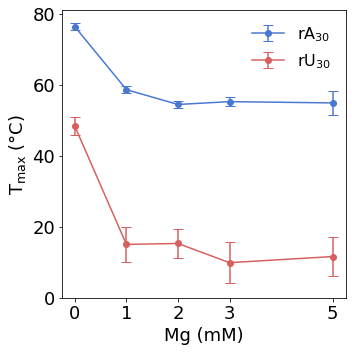

In [5]:
colors = sns.color_palette("muted") 
mg_conc = [0, 1, 2, 3, 5]
plt.figure(figsize=(5,5))
plt.errorbar(mg_conc, Tmax_rA, yerr=Tmax_se_rA, color=colors[0], fmt='o-', capsize=5, label="rA$_{30}$")
plt.errorbar(mg_conc, Tmax_rU, yerr=Tmax_se_rU, color=colors[3], fmt='o-', capsize=5, label="rU$_{30}$")
plt.yticks(np.arange(0, 100, 20))
plt.xticks([0, 1, 2, 3, 5])
plt.xlabel(r'Mg (mM)', fontsize=18)
plt.ylabel(r'$\mathrm{T_{max}}$ (°C)', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.legend(frameon=False, fontsize=16)
plt.tight_layout()
plt.savefig("Fig4C.svg", dpi=300)
plt.show()

### Fig 4D.

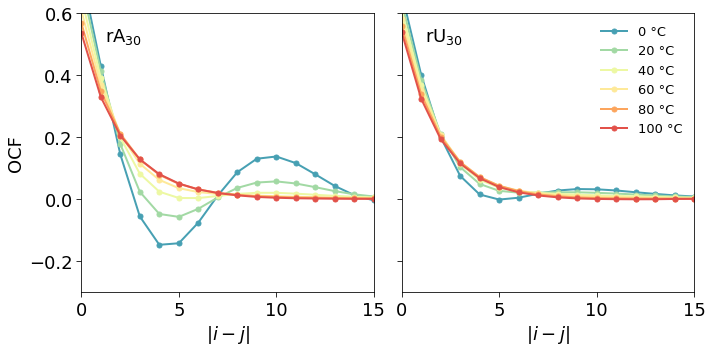

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def read_ocf(file_path):
    """Read OCF.dat and return OCF values and average P-P distance."""
    ocf = []
    avg_pp_distance = None

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            if not line or line == "Orientation_Correlation_Function":
                continue

            if "Avg P-P distance" in line:
                avg_pp_distance = float(line.split()[-1])
            else:
                ocf.append(float(line))

    return np.array(ocf), avg_pp_distance


curr_dir = os.getcwd()

temps = np.arange(0, 120, 20)
colors = sns.color_palette("Spectral_r", n_colors=len(temps))

systems = {
    "rA30": {
        "path": "rA30/Na20/Mg5",
        "label": r"rA$_{30}$",
    },
    "rU30": {
        "path": "rU30/Na20/Mg5",
        "label": r"rU$_{30}$",
    },
}


# plot
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 5),
    sharey=True
)

for ax, (system, info) in zip(axes, systems.items()):

    I_ocf = []

    for i, T in enumerate(temps):

        file_path = os.path.join(
            curr_dir,
            info["path"],
            f"t-{T}",
            "OCF.dat"
        )

        ocf, avg_pp_distance = read_ocf(file_path)

        if avg_pp_distance is not None:
            I_ocf.append(avg_pp_distance * np.sum(ocf))

        ax.plot(
            np.arange(len(ocf)),
            ocf,
            label=f"{T} °C",
            color=colors[i],
            marker="o",
            linewidth=2,
            markersize=5
        )

    ax.set_xlim(0, 15)
    ax.set_ylim(-0.3, 0.6)

    ax.set_xlabel(r"$|i-j|$", fontsize=18)
    ax.tick_params(axis="both", which="both", length=5, labelsize=18)
    ax.set_yticks(np.arange(-0.2, 0.7, 0.2))

    ax.text(
        0.08,
        0.90,
        info["label"],
        transform=ax.transAxes,
        fontsize=18
    )

axes[0].set_ylabel("OCF", fontsize=18)

axes[1].legend(
    fontsize=13,
    frameon=False,
    loc="best"
)

plt.tight_layout()
plt.savefig("Fig4D.svg", dpi=300)
plt.show()

### Fig 4E.

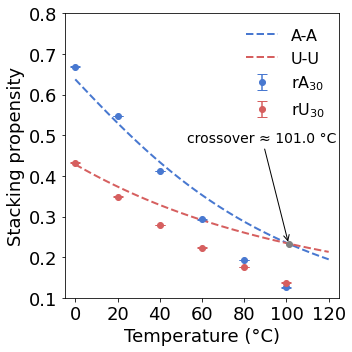

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def find_consecutive_S_lengths(seq, min_len=3):
    """Return lengths of consecutive S stretches with length >= min_len."""
    lengths = []
    count = 0

    for ch in seq:
        if ch == "S":
            count += 1
        else:
            if count >= min_len:
                lengths.append(count)
            count = 0

    if count >= min_len:
        lengths.append(count)

    return lengths


def compute_stacking_propensity(fname, min_len=3):
    """Compute frame-averaged stacking propensity from stack sequence file."""
    with open(fname) as f:
        stacks = [line.strip() for line in f if line.strip()]

    n_bases = len(stacks[0])
    propensities = []

    for seq in stacks:
        stacked_lengths = find_consecutive_S_lengths(seq, min_len=min_len)
        propensities.append(np.sum(stacked_lengths) / n_bases)

    mean = np.mean(propensities)
    sem = np.std(propensities, ddof=1) / np.sqrt(len(propensities))

    return mean, sem


def stacking_fraction(dH_kcal, dS_cal, T_C):
    """
    Two-state stacking model:
        ΔG(T) = ΔH - TΔS
        f = 1 / (1 + exp(ΔG / RT))
    """
    R = 1.987e-3  # kcal/mol/K
    T_K = T_C + 273.15
    dS_kcal = dS_cal / 1000.0
    dG = dH_kcal - T_K * dS_kcal

    return 1.0 / (1.0 + np.exp(dG / (R * T_K)))


# plotting
curr_dir = os.getcwd()

temps_sim = np.array([0, 20, 40, 60, 80, 100])
temps_model = np.linspace(0, 120, 121)

colors = sns.color_palette("muted")

systems = {
    "rA30": {
        "path": "rA30/Na20/Mg5",
        "color": colors[0],
        "label": r"rA$_{30}$",
        "model": "A-A",
    },
    "rU30": {
        "path": "rU30/Na20/Mg5",
        "color": colors[3],
        "label": r"rU$_{30}$",
        "model": "U-U",
    },
}

params = {
    "A-A": {"dH": -3.53, "dS": -11.8},
    "U-U": {"dH": -1.81, "dS": -7.2},
    "C-C": {"dH": -2.87, "dS": -10.0},
}


# simulation data
for sys_name, info in systems.items():

    means = []
    sems = []

    for T in temps_sim:
        fname = os.path.join(
            curr_dir,
            info["path"],
            f"t-{T}",
            "stack_sequences.dat"
        )

        mean, sem = compute_stacking_propensity(fname, min_len=3)

        means.append(mean)
        sems.append(sem)

    info["means"] = np.array(means)
    info["sems"] = np.array(sems)


# two state thermodynamics model
fractions = {}

for model_name, p in params.items():
    fractions[model_name] = stacking_fraction(
        p["dH"],
        p["dS"],
        temps_model
    )

# Crossover between A-A and U-U model curves
diff = fractions["A-A"] - fractions["U-U"]
idx_cross = np.argmin(np.abs(diff))
T_cross = temps_model[idx_cross]
f_cross = fractions["A-A"][idx_cross]


fig, ax = plt.subplots(figsize=(5, 5))

# Simulation points
for sys_name, info in systems.items():

    ax.errorbar(
        temps_sim,
        info["means"],
        yerr=info["sems"],
        fmt="o",
        capsize=5,
        color=info["color"],
        label=info["label"]
    )

# Model curves
for sys_name, info in systems.items():

    model_name = info["model"]

    ax.plot(
        temps_model,
        fractions[model_name],
        linestyle="--",
        linewidth=2,
        color=info["color"],
        label=model_name
    )

# Crossover annotation
ax.scatter(
    T_cross,
    f_cross,
    color="gray",
    zorder=3
)

ax.annotate(
    f"crossover ≈ {T_cross:.1f} °C",
    xy=(T_cross, f_cross),
    xytext=(T_cross - 48, f_cross + 0.25),
    arrowprops=dict(arrowstyle="->"),
    fontsize=14,
    color="black"
)

# Formatting
ax.set_xlabel(r"Temperature (°C)", fontsize=18)
ax.set_ylabel("Stacking propensity", fontsize=18)

ax.set_xlim(-5, 125)
ax.set_ylim(0.1, 0.8)

ax.set_xticks([0, 20, 40, 60, 80, 100, 120])
ax.tick_params(axis="both", which="major", labelsize=18)

ax.legend(
    loc="best",
    frameon=False,
    fontsize=16
)

plt.tight_layout()

plt.savefig("Fig4E.svg", dpi=300)

plt.show()